In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors


from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from collections import Counter
from tqdm.notebook import tqdm
from deeptime.clustering import KMeans
from deeptime.clustering import RegularSpace
from deeptime.clustering import BoxDiscretization
import pandas as pd 
import pyemma

import mdtraj as md
import re, math, os, shutil, pickle

import warnings; warnings.simplefilter('ignore')
from collections import Counter

## Important Functions

In [2]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)

In [3]:
# Define the directory path
directory = "clustering/"

remove_and_clean = False

# Check if the directory exists
if os.path.exists(directory):
    if remove_and_clean:
        # Remove all contents of the directory
        shutil.rmtree(directory)
        # Recreate the empty directory
        os.makedirs(directory)
        print(f"All contents in '{directory}' have been cleared.")
    else:
        print(f"Directory '{directory}' already exists. No action taken.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

Directory 'clustering/' already exists. No action taken.


## Load the data

In [4]:
## Load Distance Restraubt Data 
dist_path = f"traj_data/dist_state0.pkl"
dist = Data.load(dist_path)
dist = dist.array_list
print(f'dist.shape:{np.array(dist).shape}')

## Load Backbone Phi Omega angle 
omega_path = f"traj_data/omegas_state0.pkl"
omegas = Data.load(omega_path)
omegas = omegas.array_list
print(f'omegas.shape: {np.array(omegas).shape}')

residues_to_plot = np.arange(0, 36, 4).tolist()  # Modify if needed

omega_indices = [r for r in residues_to_plot]
phi_indices   = [r + 1 for r in residues_to_plot]
psi_indices   = [r + 2 for r in residues_to_plot]
chi1_indices  = [r + 3 for r in residues_to_plot]

for angle_indices in [omega_indices, psi_indices, chi1_indices]:
    omegas[:, angle_indices] = (omegas[:, angle_indices] + 90.0) % 360.0 - 90.0

feat_all = np.hstack([dist,omegas])
print('feat_all.shape', feat_all.shape)

dist.shape:(300015, 156)
omegas.shape: (300015, 36)
feat_all.shape (300015, 192)


## Clustering with Selected Backbone Angle 

In [5]:
residues_to_plot = np.arange(0, 36, 4).tolist()  # Modify if needed
omega_features = feat_all[:, -36:]              # Get the last 24 columns
selected_omegas = omega_features[:, residues_to_plot]
selected_phi = omega_features[:, [i + 1 for i in residues_to_plot]]
selected_psi = omega_features[:, [i + 2 for i in residues_to_plot]]
selected_khi = omega_features[:, [i + 3 for i in residues_to_plot]]

In [6]:
omega_binary = (selected_omegas > 90).astype(int)  # 1 if > 90, else 0
phi_binary = (selected_phi > 0).astype(int)        # 1 if > 0, else 0


In [7]:
backbone_signature = np.hstack([omega_binary, phi_binary])  # shape (200010, 12)
backbone_signature.shape

(300015, 18)

In [8]:
# Convert each row to a tuple so they are hashable
signatures = [tuple(row) for row in backbone_signature]

# Map to integer labels
df_signatures = pd.DataFrame(signatures, columns=[f"f{i}" for i in range(18)])
df_signatures["cluster_label"] = pd.factorize(signatures)[0]  # returns labels 0, 1, 2, ...

# Final cluster labels:
assignments = df_signatures["cluster_label"].to_numpy()

assignments.shape

(300015,)

In [9]:
# count the number of each cluter 
counts = Counter(assignments)
#print(counts)

# Sort the counts 
sorted_counts = dict(sorted(counts.items()))
total_counts = sum(counts.values())
cluster = []

# Create a DataFrame to hold results
data = {
    "Cluster Label": [],
    "Count": [],
    "Population": []
}

for label, frequency in sorted_counts.items():    
    percentage = (frequency / total_counts) * 100 
    data["Cluster Label"].append(label)
    data["Count"].append(frequency)
    data["Population"].append(round(percentage, 4))  # round for cleaner display
    #print(f"Assignment {label}: {frequency}, {percentage:.4g}%")

# Convert to DataFrame
df_cluster = pd.DataFrame(data)

# Save to CSV
df_cluster.to_csv("clustering/cluster_percentages.csv", index=False)
df_cluster

,Cluster Label,Count,Population
0,0,311,0.1037
1,1,201,0.0670
2,2,388,0.1293
3,3,65,0.0217
4,4,168,0.0560
...,...,...,...
351,351,1,0.0003
352,352,8,0.0027
353,353,23,0.0077
354,354,809,0.2697


## Analysis Top Labels

In [10]:
# Example input (either form)
#top_n = 5                     # automatic selection
# top_n = [2, 5, 7]              # manual selection
top_n = [ 153,   6,   2,  78, 166]                  # manually selected cluster 10

# Process top clusters
if isinstance(top_n, int):
    # Automatically choose top-N most populated clusters
    top = sorted(sorted_counts.items(), key=lambda x: x[1], reverse=True)[:top_n]
elif isinstance(top_n, list):
    # Manually specified cluster labels
    top = [(label, sorted_counts[label]) for label in top_n if label in sorted_counts]
else:
    raise ValueError("top_n must be either an int or a list of cluster labels.")


print(f"Top {top_n} most populated clusters:")
for label, count in top:
    percentage = (count / total_counts) * 100
    print(f"Assignment {label}: {count} frames, {percentage:.4g}%")


Top [153, 6, 2, 78, 166] most populated clusters:
Assignment 153: 28666 frames, 9.555%
Assignment 6: 4701 frames, 1.567%
Assignment 2: 388 frames, 0.1293%
Assignment 78: 21001 frames, 7%
Assignment 166: 6064 frames, 2.021%


In [11]:
top_cluster = {label: [] for label in top_n}

for label in top_cluster:
    indices = np.where(assignments == label)[0]  # These are the frame indices
    top_cluster[label] = indices  # Just store the indices directly
    # Print label and first few indices
    example_indices = indices[:5]  # first 5 indices
    print(f"Cluster {label}: {len(indices)} frames — example indices: {example_indices}")


Cluster 153: 28666 frames — example indices: [52339 52343 52344 52379 52400]
Cluster 6: 4701 frames — example indices: [ 38  41 139 145 155]
Cluster 2: 388 frames — example indices: [ 5  7 10 11 12]
Cluster 78: 21001 frames — example indices: [19143 19145 19146 19152 19156]
Cluster 166: 6064 frames — example indices: [61311 61312 61313 61322 61323]


## Analysis the Ensembles

In [12]:
## cluster with indices 

cluster = {label: [] for label in np.unique(assignments)}

for label in cluster:
    indices = np.where(assignments == label)[0]  # These are the frame indices
    cluster[label] = indices  # Just store the indices directly

# Find the cluster with the fewest frames
min_label, min_size = min(((label, len(frames)) for label, frames in cluster.items()), key=lambda x: x[1])
print(f"Cluster {min_label} has the fewest frames: {min_size}")


Cluster 41 has the fewest frames: 1


In [13]:
cluster_frame_dist = {}

for label in tqdm(np.unique(assignments)):
    data = []
    for idx in cluster[label]:  # idx is the frame index
        dist_row = dist[idx] 
        data.append((idx, dist_row))
    cluster_frame_dist[label] = data


  0%|          | 0/356 [00:00<?, ?it/s]

In [14]:
sample_size = 50
np.random.seed(42)  # For reproducibility

sampled_distances = {label: [] for label in np.unique(assignments)}

for label, items in tqdm(cluster_frame_dist.items()):
    cluster_size = len(items)

    # Use the smaller of sample_size or cluster_size
    current_sample_size = min(sample_size, cluster_size)
    
    if current_sample_size < sample_size:
        print(f"Cluster {label} has only {cluster_size} items — sampling {current_sample_size} instead of {sample_size}")

    # Randomly sample indices
    sampled_indices = np.random.choice(cluster_size, current_sample_size, replace=False)

    # Extract sampled distance rows only
    sampled = [items[i] for i in sampled_indices]  # (idx, dist_row)
    sampled_distances[label] = np.array([dist for (_, dist) in sampled])


  0%|          | 0/356 [00:00<?, ?it/s]

Cluster 9 has only 40 items — sampling 40 instead of 50
Cluster 10 has only 7 items — sampling 7 instead of 50
Cluster 15 has only 2 items — sampling 2 instead of 50
Cluster 24 has only 10 items — sampling 10 instead of 50
Cluster 25 has only 32 items — sampling 32 instead of 50
Cluster 26 has only 6 items — sampling 6 instead of 50
Cluster 27 has only 9 items — sampling 9 instead of 50
Cluster 29 has only 4 items — sampling 4 instead of 50
Cluster 33 has only 2 items — sampling 2 instead of 50
Cluster 35 has only 10 items — sampling 10 instead of 50
Cluster 38 has only 35 items — sampling 35 instead of 50
Cluster 39 has only 2 items — sampling 2 instead of 50
Cluster 40 has only 26 items — sampling 26 instead of 50
Cluster 41 has only 1 items — sampling 1 instead of 50
Cluster 42 has only 1 items — sampling 1 instead of 50
Cluster 44 has only 44 items — sampling 44 instead of 50
Cluster 45 has only 20 items — sampling 20 instead of 50
Cluster 51 has only 42 items — sampling 42 instead

In [15]:
### Calculate the average distance of each clusters  

average_distances = {} ## Create (n_cluster, ave_dist)
cluster_average_dist = []

for label, dist_array in tqdm(sampled_distances.items()):
    # dist_array: shape (sample_size, 76)
    avg_dist = dist_array.mean(axis=0)  # average across samples → shape (76,)
    average_distances[label] = avg_dist
    cluster_average_dist.append(avg_dist)

# Convert to DataFrame saving for biceps 
df_MD_dist = pd.DataFrame(cluster_average_dist)

# Save to CSV
df_MD_dist.to_csv("clustering/md_distances.csv", index=False)
df_MD_dist


  0%|          | 0/356 [00:00<?, ?it/s]

,0,1,2,3,4,5,6,7,8,9,...,146,147,148,149,150,151,152,153,154,155
0,2.757354,2.261939,2.737007,2.801979,8.694685,7.896088,10.196002,9.393167,3.164297,3.365721,...,3.976268,4.754559,3.900674,4.643639,3.833561,4.512707,3.817227,2.310493,3.854804,2.486085
1,2.602989,2.262156,2.952681,2.581653,6.965965,5.909644,7.893921,6.803773,2.839907,3.732733,...,3.541401,4.544718,3.736775,4.654038,3.511376,4.421729,3.673225,2.143404,4.095656,2.875006
2,2.941394,2.493743,2.385592,2.929634,7.248221,7.184501,5.707003,5.718819,2.969799,3.759898,...,3.913333,4.565033,3.869337,4.639298,4.061522,4.819835,3.698257,2.165194,3.957031,2.656621
3,2.750487,2.238288,2.749055,2.781483,9.658091,8.586473,11.092550,9.983387,2.917984,3.675023,...,3.685375,4.465912,3.756933,4.504766,4.015421,4.831041,3.758124,2.219808,3.946898,2.603960
4,2.862438,2.354358,2.514330,2.884757,5.887539,4.845164,5.173846,4.168424,3.137954,3.833574,...,4.092302,4.550902,4.015624,4.315746,3.875497,4.265635,3.671270,2.213820,4.026363,2.789347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,3.060588,2.496358,2.641401,2.979967,5.654856,4.634868,4.012232,2.887803,2.525096,3.558554,...,3.644836,4.614827,3.813547,5.102269,2.497836,3.970692,1.916690,3.467161,3.562108,4.836147
352,2.703611,2.892843,2.248357,2.727931,12.188668,12.859446,10.888669,11.581291,3.087606,3.655791,...,3.722124,4.478209,3.879911,4.717907,3.971642,4.618060,4.241796,2.721997,3.605882,2.169249
353,2.837107,2.278593,2.595139,2.858791,13.779226,12.997114,12.540729,11.700872,3.442959,3.621753,...,3.795666,4.378435,3.924321,4.516828,3.875494,4.444449,3.610825,2.143091,4.645367,3.570435
354,2.674949,2.438095,2.628310,2.692179,13.021537,12.776111,11.541277,11.310620,2.886346,3.313800,...,3.357833,4.485132,3.369736,4.466823,3.227023,4.379487,2.209859,3.692126,2.471926,3.883071


In [16]:

### Creat a list to store for each 76 distance, store the average value of those cluster (dist, n_cluster)
average_distances_list = []

# Get sorted list of labels
cluster_labels = sorted(average_distances.keys())  # e.g., [0, 1, 2, ..., 499]
n_clusters = len(cluster_labels)

# Initialize a matrix: rows = 76 distances, cols = cluster labels
average_distances_array = np.zeros((156, n_clusters))

for j, label in enumerate(cluster_labels):  # j = column index
    average_distances_array[:, j] = average_distances[label]  # shape (76,)



## Refer NMR Labels

In [17]:
restraints_table = {
    'weak': 5,
    'medium': 3.5,
    'strong': 2.5
}

dist_res_file = '../../../utils/nspe_10_restraints.csv'
df_dist_res = pd.read_csv(dist_res_file)

for i, row in df_dist_res.iterrows():
    df_dist_res.at[i, df_dist_res.columns[2]] = restraints_table[row[2]]  # Correct mapping

# Make a look up table for intensity 
df_dist_res
dist_res = df_dist_res.values.tolist()
dist_res[:5]

[[24, 13, 5], [24, 14, 5], [25, 13, 5], [25, 14, 5], [137, 13, 5]]

In [18]:
atomtype_lookup = {
    ('H02', 'H12'): 'α11',
    ('H02', 'H13'): 'α11',
    ('H02', 'H1'): 'NH+',
    ('H02', 'H2'): 'NH+',
    ('H02', 'H3'): 'α2',
    ('H02', 'H4'): 'β3',
    ('H02', 'H5'): 'β3',
    ('H02', 'H6'): 'β3',
    ('R02', 'H10'): 'α11',
    ('R02', 'H11'): 'α11',
    ('R02', 'H1'): 'α2',
    ('R02', 'H2'): 'β3',
    ('R02', 'H3'): 'β3',
    ('R02', 'H4'): 'β3',
    ('NH2', 'HN1'): 'NH1',
    ('NH2', 'HN2'): 'NH1',
}  

In [19]:
def translate_pyemma_label(label):
    # Remove 'DIST: ' prefix and whitespace
    label = label.replace('DIST: ', '').strip()
    
    # Split into two atoms
    part1, part2 = label.split(' - ')
    resname1, resid1, atomname1, atomid1 = part1.split()
    resname2, resid2, atomname2, atomid2 = part2.split()

    # Lookup group for each atom
    group1 = atomtype_lookup.get((resname1, atomname1), 'unknown')
    group2 = atomtype_lookup.get((resname2, atomname2), 'unknown')

    # Print (optional)
    print(f"Label: {label}")
    print(f"Residue 1: {resname1} {resid1}, Atom: {atomname1} ({atomid1}), Group: {group1}")
    print(f"Residue 2: {resname2} {resid2}, Atom: {atomname2} ({atomid2}), Group: {group2}")

    # Return formatted result
    return f"{resid1}{group1}-{resid2}{group2}"


In [20]:
# Settings
human_interpretable_label = True
grofile = "../nspe_10.amb2gmx/nspe_10_GMX.gro"

# Prepare label cache
labels = []
targets = []

for atom1, atom2, target in dist_res:
    targets.append(target)

    atom1_pyemma = atom1 - 1
    atom2_pyemma = atom2 - 1
    feat = pyemma.coordinates.featurizer(grofile)
    feat.add_distances([[atom1_pyemma, atom2_pyemma]])
    raw_label = feat.describe()[0]

    if human_interpretable_label:
        label = translate_pyemma_label(label=raw_label)
    else:
        label = raw_label

    labels.append(label)

targets = np.array(targets)
labels[0]


Label: H02 1 H12 23 - H02 1 H1 12
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H12 23 - H02 1 H2 13
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H02 1 H13 24 - H02 1 H1 12
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H13 24 - H02 1 H2 13
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H10 136 - H02 1 H1 12
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H10 136 - H02 1 H2 13
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H11 137 - H02 1 H1 12
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H11 137 - H02 1 H2 13
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H

'1α11-1NH+'

In [21]:
 
df_labels = pd.DataFrame(labels)
df_labels.to_csv("clustering/human_readable_labels.csv", index=False)
df_labels


,0
0,1α11-1NH+
1,1α11-1NH+
2,1α11-1NH+
3,1α11-1NH+
4,6α11-1NH+
...,...
151,2β3-2α11
152,8α11-9α11
153,8α11-9α11
154,8α11-9α11


## Plot Ensembles Distances

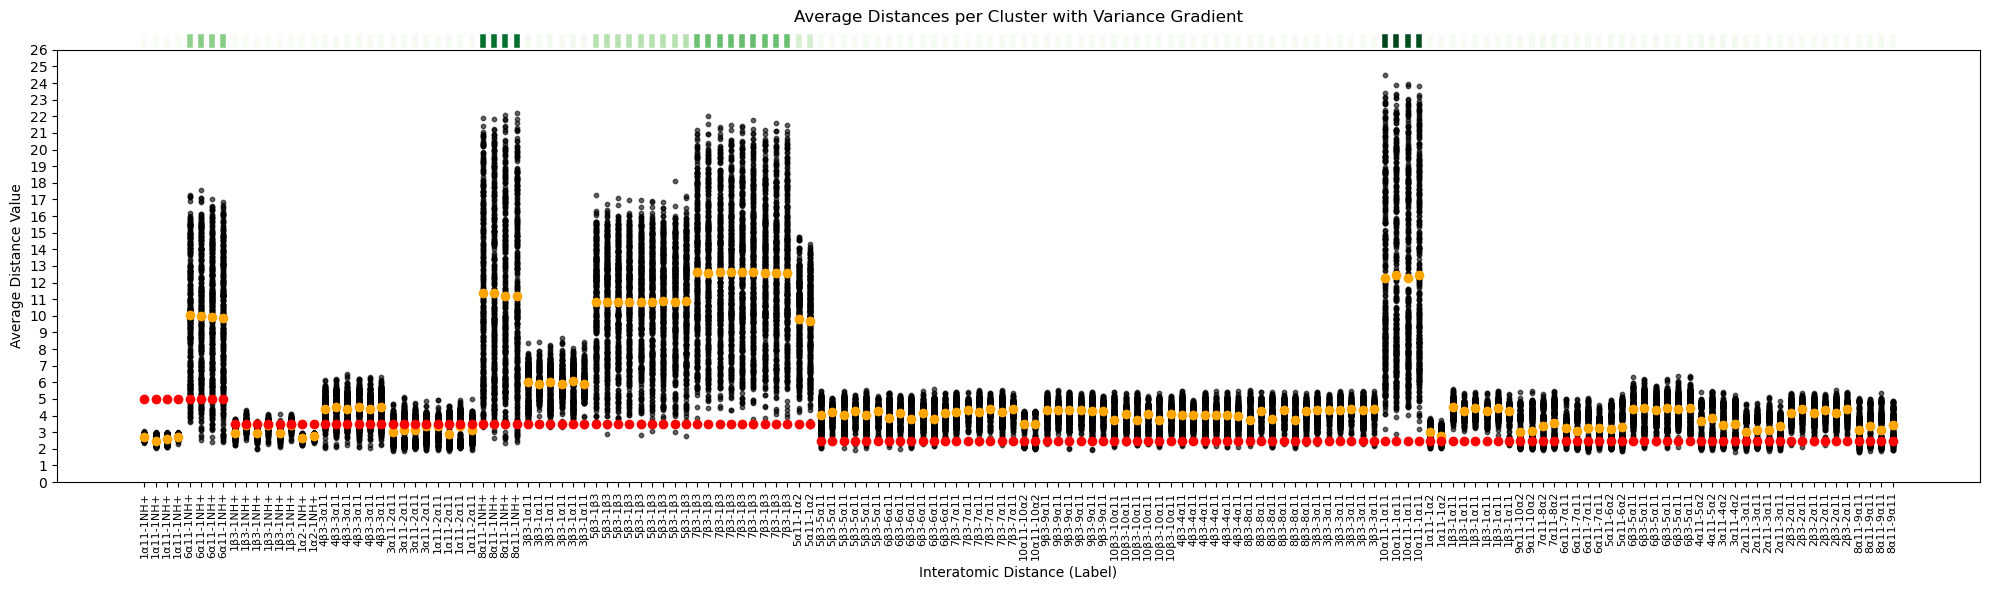

In [22]:
mean_across_clusters = average_distances_array.mean(axis=1)     # shape (76,)
var_across_clusters = average_distances_array.var(axis=1)       # shape (76,)
# Normalize the variance values to 0–1 for colormap
norm = mcolors.Normalize(vmin=var_across_clusters.min(), vmax=var_across_clusters.max())
cmap = cm.Greens  # or another colormap
colors = cmap(norm(var_across_clusters))  # shape: (76, 4) — RGBA colors


plt.figure(figsize=(20, 6))


# Scatter plot: one color per cluster
for j, label_id in enumerate(cluster_labels):
    plt.scatter(range(156), average_distances_array[:, j], color='black',
            s=10, alpha=0.6)
plt.scatter(range(156), mean_across_clusters, color='orange')
plt.scatter(range(156), targets, color='red')
for i in range(156):
    plt.axvline(x=i, ymin=1.01, ymax=1.03, color=colors[i], linewidth=4, clip_on=False)


# X-axis ticks as human-readable labels
plt.xticks(ticks=np.arange(156), labels=labels, rotation=90, fontsize=8)
plt.yticks(ticks=np.arange(0, plt.ylim()[1] + 1, 1))  # interval = 1
plt.xlabel("Interatomic Distance (Label)")
plt.ylabel("Average Distance Value")
plt.title("Average Distances per Cluster with Variance Gradient", pad=20)
plt.tight_layout()
plt.show()


In [23]:
average_distances_array_T = average_distances_array.T 
print('average_distances_array_T.shape', average_distances_array_T.shape)

rmsd = np.sqrt(np.mean((average_distances_array_T - targets) ** 2, axis=1))
rmsd.shape



average_distances_array_T.shape (356, 156)


(356,)

In [24]:
# Get indices of clusters sorted by RMSD
sorted_indices = np.argsort(rmsd)

# Get the smallest five
top5_indices = sorted_indices[:5]
top5_indices = np.array([153,   6,   2,  78, 166])
#top5_indices = np.array([ 153])
top5_rmsd = rmsd[top5_indices]

# Print them
for rank, (idx, val) in enumerate(zip(top5_indices, top5_rmsd), 1):
    print(f"{rank}. Cluster {idx} → RMSD = {val:.4f}")

top5_indices


1. Cluster 153 → RMSD = 1.9222
2. Cluster 6 → RMSD = 2.0175
3. Cluster 2 → RMSD = 1.8143
4. Cluster 78 → RMSD = 2.2427
5. Cluster 166 → RMSD = 2.2466


array([153,   6,   2,  78, 166])

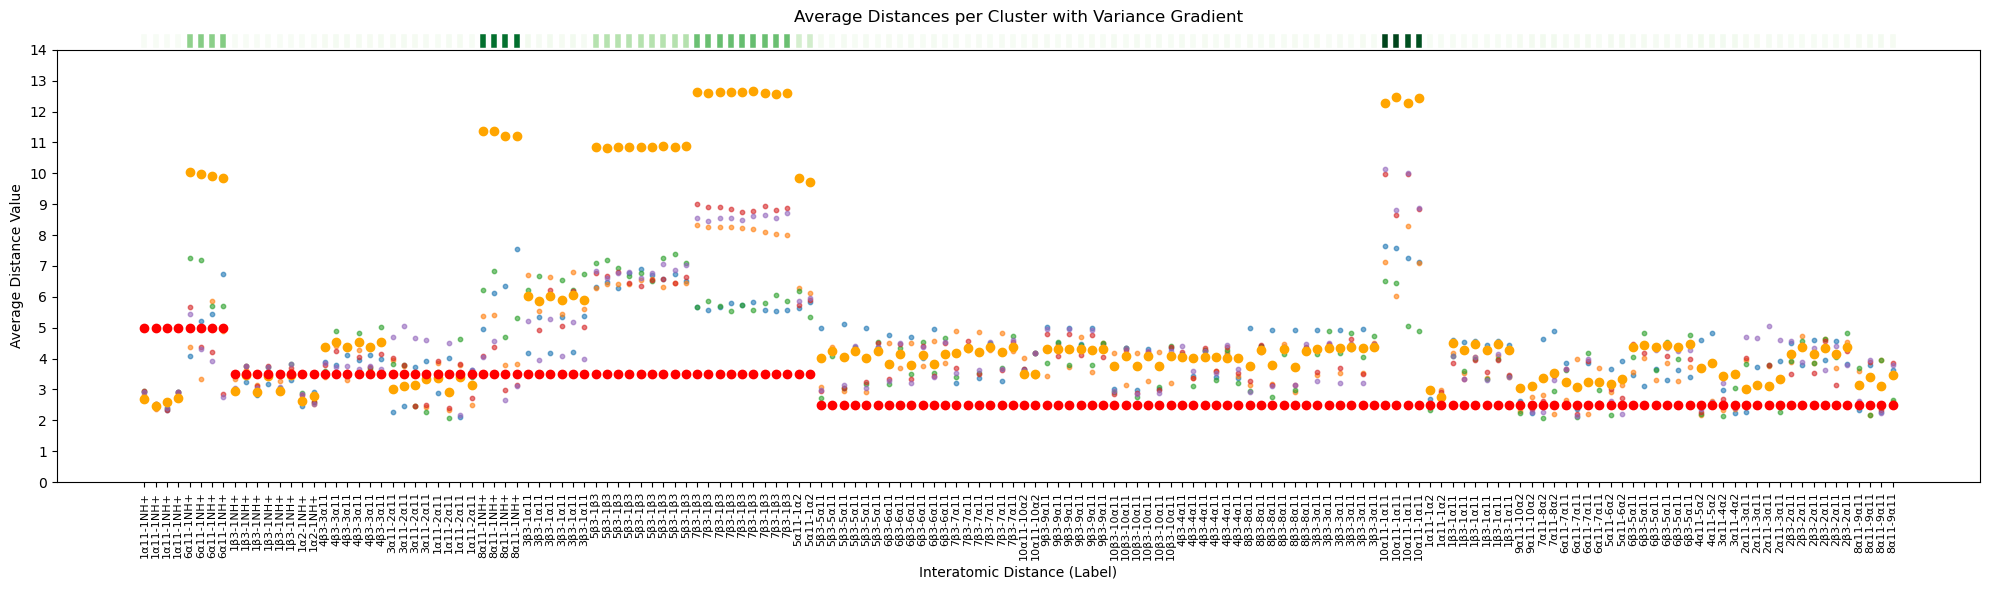

In [25]:
mean_across_clusters = average_distances_array.mean(axis=1)     # shape (76,)
var_across_clusters = average_distances_array.var(axis=1)       # shape (76,)
# Normalize the variance values to 0–1 for colormap
norm = mcolors.Normalize(vmin=var_across_clusters.min(), vmax=var_across_clusters.max())
cmap = cm.Greens  # or another colormap
colors = cmap(norm(var_across_clusters))  # shape: (76, 4) — RGBA colors


plt.figure(figsize=(20, 6))


# Only plot top 5 lowest-RMSD clusters
for cluster_idx in top5_indices:
    plt.scatter(range(156), average_distances_array_T[cluster_idx], 
                s=10, alpha=0.6, label=f'Cluster {cluster_idx}')
plt.scatter(range(156), mean_across_clusters, color='orange')
plt.scatter(range(156), targets, color='red')
for i in range(156):
    plt.axvline(x=i, ymin=1.01, ymax=1.03, color=colors[i], linewidth=4, clip_on=False)


# X-axis ticks as human-readable labels
plt.xticks(ticks=np.arange(156), labels=labels, rotation=90, fontsize=8)
plt.yticks(ticks=np.arange(0, plt.ylim()[1] + 1, 1))  # interval = 1
plt.xlabel("Interatomic Distance (Label)")
plt.ylabel("Average Distance Value")
plt.title("Average Distances per Cluster with Variance Gradient", pad=20)
plt.tight_layout()
plt.show()


## Analaysis Each Cluster Distance Distribution

Label: H02 1 H12 23 - H02 1 H1 12
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H12 23 - H02 1 H2 13
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H02 1 H13 24 - H02 1 H1 12
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H13 24 - H02 1 H2 13
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H10 136 - H02 1 H1 12
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H10 136 - H02 1 H2 13
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H11 137 - H02 1 H1 12
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H11 137 - H02 1 H2 13
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H

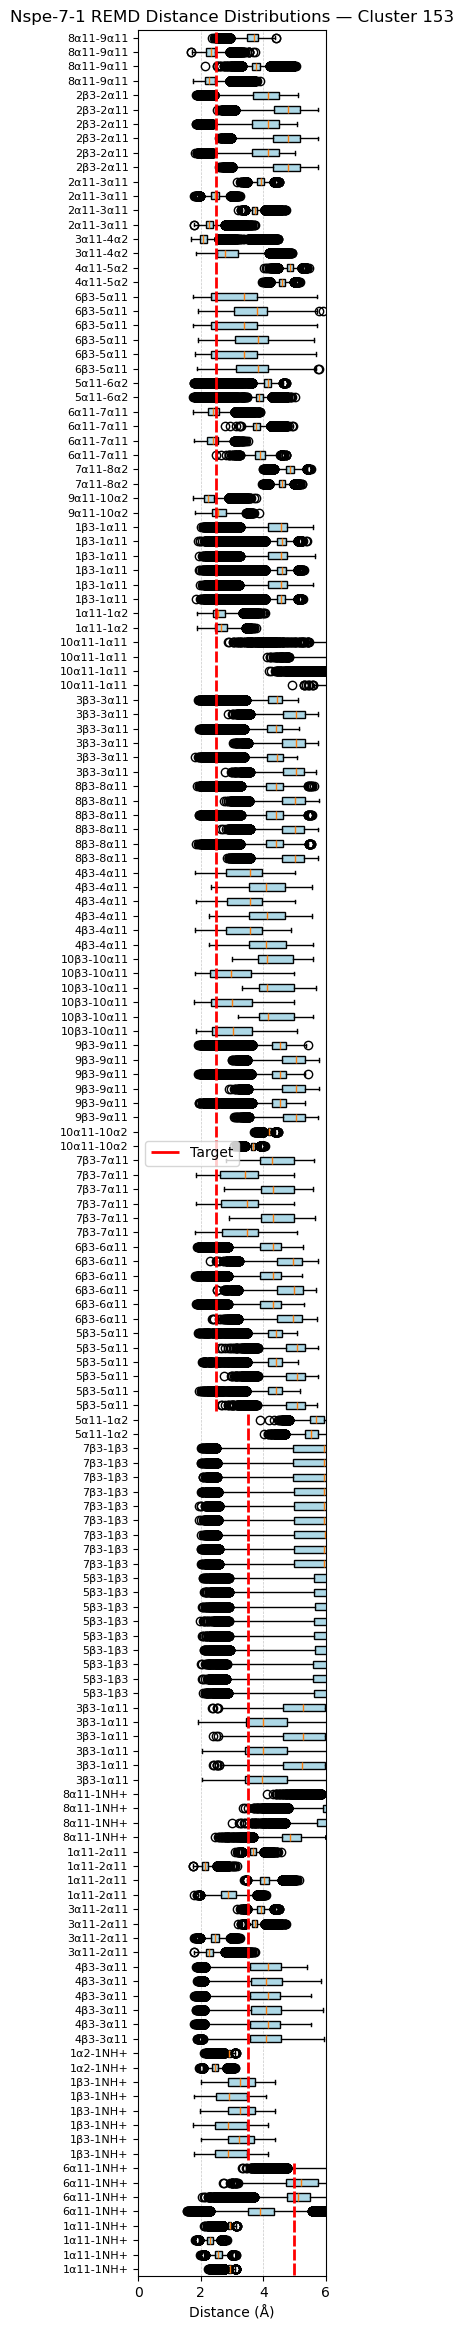

Label: H02 1 H12 23 - H02 1 H1 12
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H12 23 - H02 1 H2 13
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H02 1 H13 24 - H02 1 H1 12
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H13 24 - H02 1 H2 13
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H10 136 - H02 1 H1 12
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H10 136 - H02 1 H2 13
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H11 137 - H02 1 H1 12
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H11 137 - H02 1 H2 13
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H

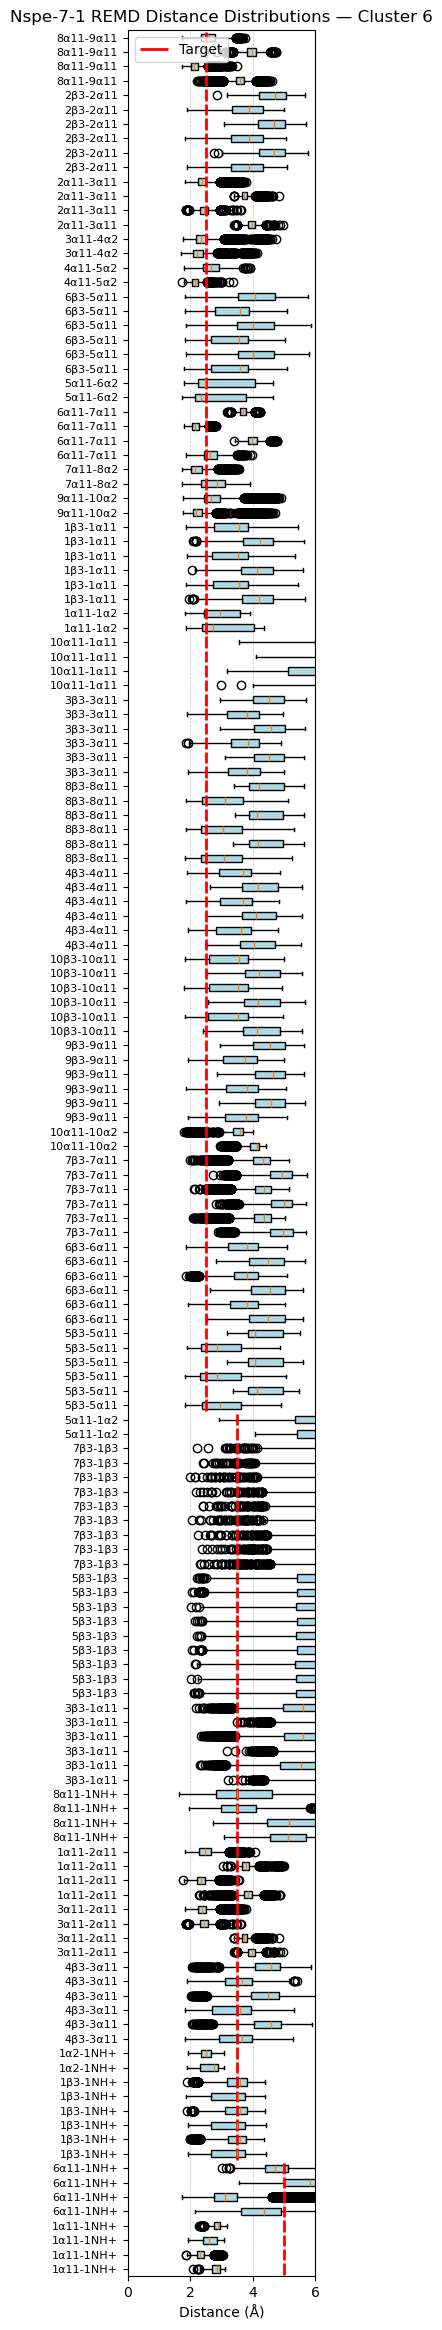

Label: H02 1 H12 23 - H02 1 H1 12
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H12 23 - H02 1 H2 13
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H02 1 H13 24 - H02 1 H1 12
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H13 24 - H02 1 H2 13
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H10 136 - H02 1 H1 12
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H10 136 - H02 1 H2 13
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H11 137 - H02 1 H1 12
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H11 137 - H02 1 H2 13
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H

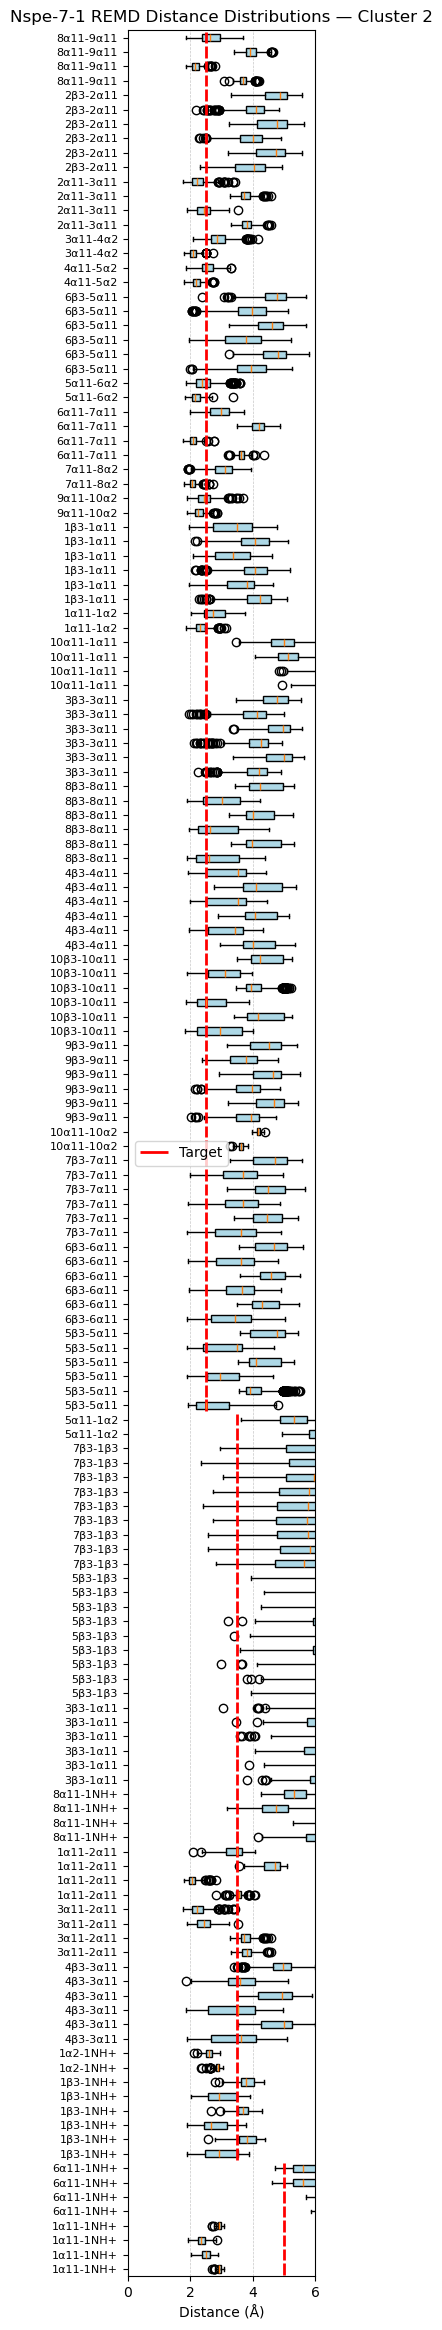

Label: H02 1 H12 23 - H02 1 H1 12
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H12 23 - H02 1 H2 13
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H02 1 H13 24 - H02 1 H1 12
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H13 24 - H02 1 H2 13
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H10 136 - H02 1 H1 12
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H10 136 - H02 1 H2 13
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H11 137 - H02 1 H1 12
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H11 137 - H02 1 H2 13
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H

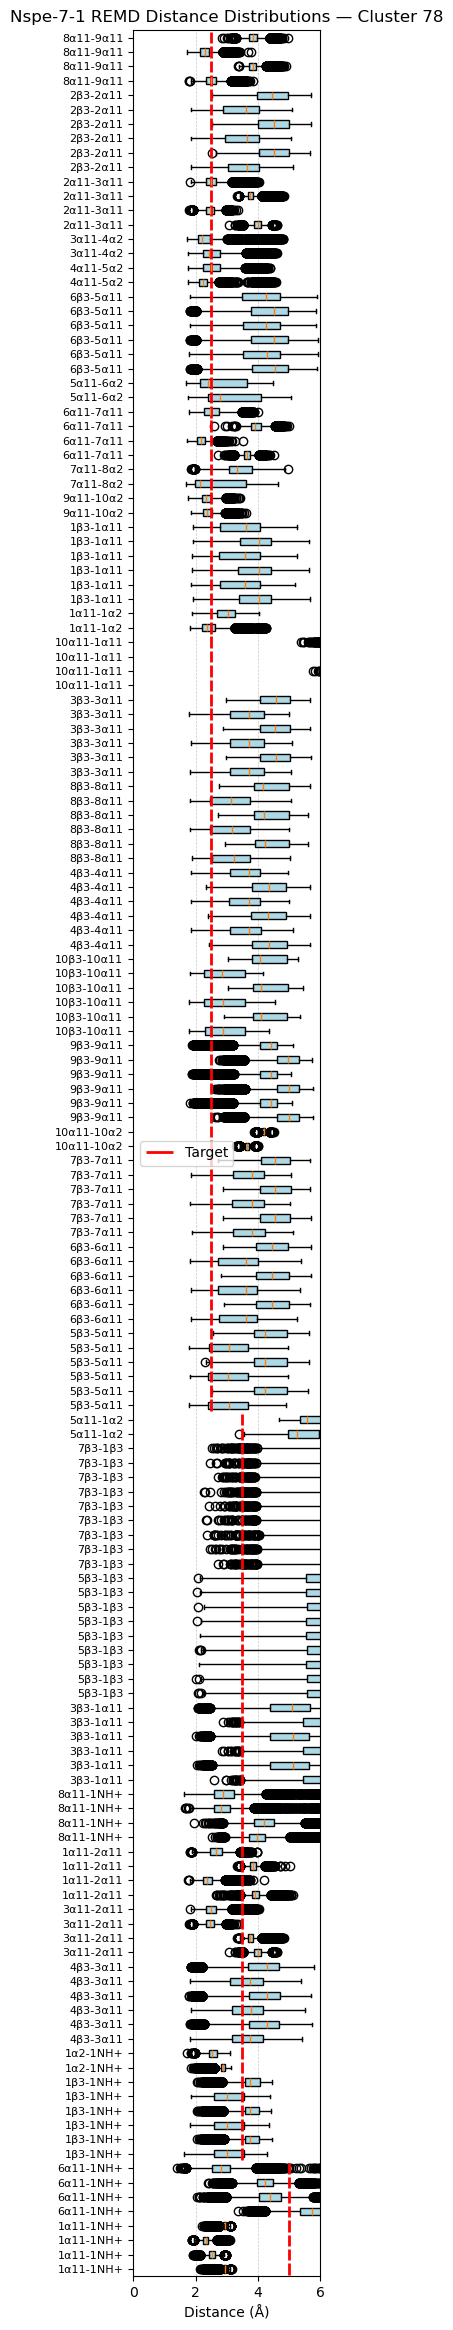

Label: H02 1 H12 23 - H02 1 H1 12
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H12 23 - H02 1 H2 13
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H02 1 H13 24 - H02 1 H1 12
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H13 24 - H02 1 H2 13
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H10 136 - H02 1 H1 12
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H10 136 - H02 1 H2 13
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H11 137 - H02 1 H1 12
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H11 137 - H02 1 H2 13
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H

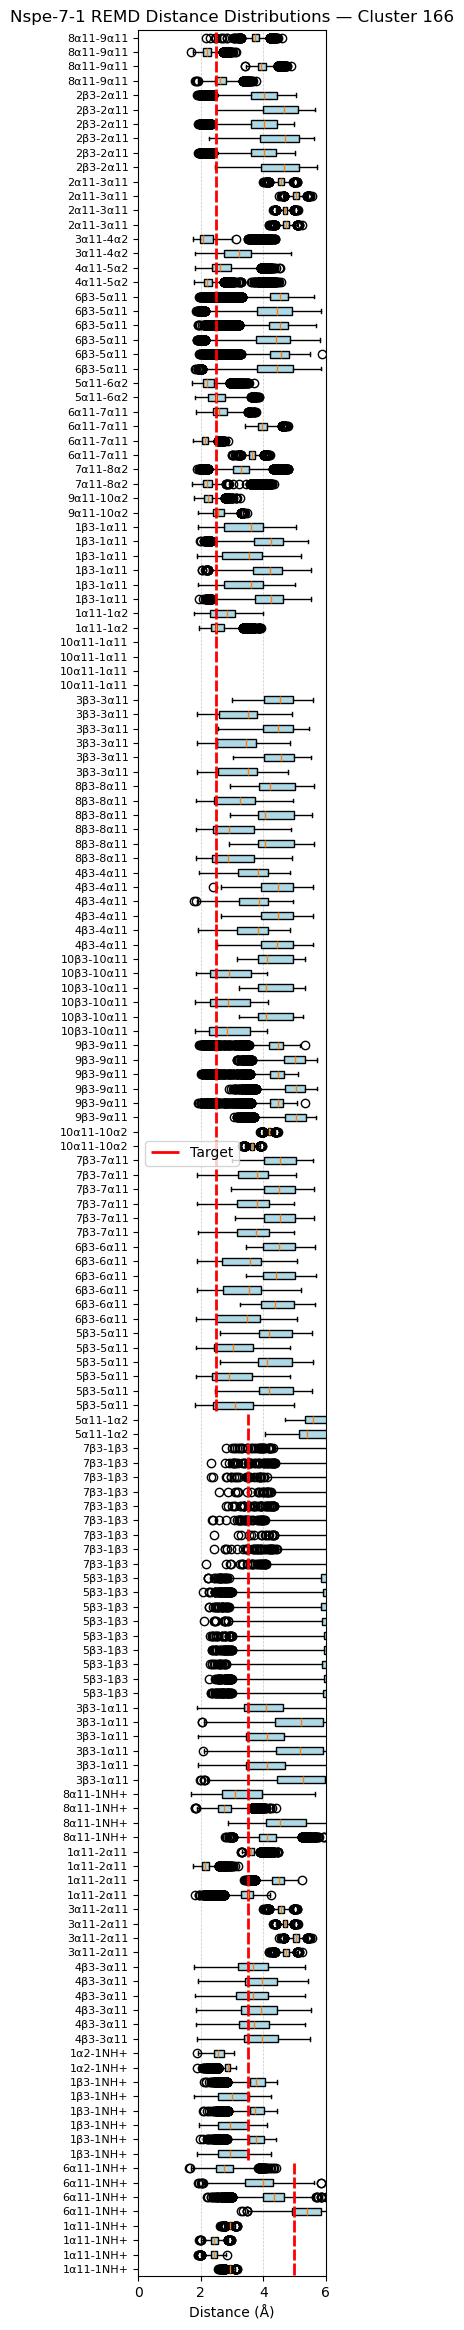

In [26]:
human_interpretable_label = True
grofile = "../nspe_10.amb2gmx/nspe_10_GMX.gro"

for cluster_label, frame_indices in top_cluster.items():
    targets = []
    labels = []
    all_dists = []

    cluster_feat = feat_all[frame_indices]
    dist_feat = cluster_feat[:, :156]

    for i, (atom1, atom2, target) in enumerate(dist_res):
        dist = dist_feat[:, i]
        all_dists.append(dist)
        targets.append(target)

        atom1_pyemma = atom1 - 1
        atom2_pyemma = atom2 - 1
        feat = pyemma.coordinates.featurizer(grofile)
        feat.add_distances([[atom1_pyemma, atom2_pyemma]])
        label = feat.describe()[0]

        if human_interpretable_label:
            #labels.append(f"{i}: {translate_pyemma_label(label=label)}")
            labels.append(f"{translate_pyemma_label(label=label)}")
        else:
            labels.append(label)

    targets = np.array(targets)

    plt.figure(figsize=(3, max(6, len(labels) * 0.15)))

    # Boxplot: transpose the list of arrays into required format
    bp = plt.boxplot(all_dists, vert=False, patch_artist=True, labels=labels)

    # Custom styling for boxes
    for box in bp['boxes']:
        box.set(facecolor='lightblue')

    # Add red target lines
    for yi, ti in enumerate(targets, start=1):  # boxplot y starts at 1
        plt.vlines(ti, yi - 0.4, yi + 0.4, colors='red', linestyles='-', linewidth=2, label='Target' if yi == 1 else "")

    plt.yticks(fontsize=8)
    plt.xlabel("Distance (Å)")
    plt.title(f"Nspe-7-1 REMD Distance Distributions — Cluster {cluster_label}")
    plt.xlim(0, 6)
    plt.legend()
    plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()


## Analysis Dihedral

In [34]:
def plot_dihedral_quadruplets(
    omega_all,
    residues_to_plot,
    states=range(16),
    use_latex=True,
    angles_to_plot=None
):
    """
    Plot selected dihedral angle pairs for each residue in each state.

    Parameters:
    -----------
    omega_all : np.ndarray
        Shape (n_states, n_frames, n_dihedrals)
    residues_to_plot : list of int
        Starting indices of each residue block (omega, phi, psi, chi1)
    states : list
        Indices of states to plot
    use_latex : bool
        Use LaTeX formatting for labels
    angles_to_plot : list of str
        Angle pairs to plot. Options:
            'omega_phi', 'omega_psi', 'phi_psi',
            'omega_chi1', 'phi_chi1', 'psi_chi1'
    """
    if angles_to_plot is None:
        angles_to_plot = ["omega_phi", "omega_psi", "phi_psi", "omega_chi1", "phi_chi1", "psi_chi1"]

    scatter_kws = dict(s=2, color='black', alpha=0.3)

    # Axis labels
    if use_latex:
        labels = {
            'phi': r'$\phi$',
            'psi': r'$\psi$',
            'omega': r'$\omega$',
            'chi1': r'$\chi_1$'
        }
    else:
        labels = {
            'phi': 'Phi',
            'psi': 'Psi',
            'omega': 'Omega',
            'chi1': 'Chi1'
        }

    def format_ax(ax, xlabel, ylabel):
        """Set axis limits and ticks based on dihedral type."""
        if labels['phi'] in xlabel:
            ax.set_xlim(-180, 180)
            ax.set_xticks(np.arange(-180, 181, 180))
        else:
            ax.set_xlim(-90, 270)
            ax.set_xticks(np.arange(-90, 271, 180))

        if labels['phi'] in ylabel:
            ax.set_ylim(-180, 180)
            ax.set_yticks(np.arange(-180, 181, 180))
        else:
            ax.set_ylim(-90, 270)
            ax.set_yticks(np.arange(-90, 271, 180))

        ax.set_xlabel(xlabel, labelpad=4)
        ax.set_ylabel(ylabel, labelpad=4)

    # Mapping from angle pair name to (x, y) keys and title suffix
    angle_plot_map = {
        'omega_phi':   ('phi',   'omega'),
        'omega_psi':   ('psi',   'omega'),
        'phi_psi':     ('psi',   'phi'),
        'omega_chi1':  ('chi1',  'omega'),
        'phi_chi1':    ('chi1',  'phi'),
        'psi_chi1':    ('chi1',  'psi'),
    }

    for state_idx in states:
        num_residues = len(residues_to_plot)
        num_pairs = len(angles_to_plot)
        nrows = num_residues
        ncols = num_pairs

        fig, axes = plt.subplots(nrows, ncols, figsize=(1.5 * ncols, 0.7 * nrows), sharex='col')
        axes = np.atleast_2d(axes)

        fig.suptitle(f'Nspe_7_1 — State {state_idx} REMD (Distances Restrainted OFF)', fontsize=10)

        for row_idx, residue in enumerate(residues_to_plot):
            omega = omega_all[state_idx, :, residue]
            phi   = omega_all[state_idx, :, residue + 1]
            psi   = omega_all[state_idx, :, residue + 2]
            chi1  = omega_all[state_idx, :, residue + 3]

            angle_data = {
                'omega': omega,
                'phi':   phi,
                'psi':   psi,
                'chi1':  chi1,
            }

            for col_idx, angle_pair in enumerate(angles_to_plot):
                x_key, y_key = angle_plot_map[angle_pair]
                x = angle_data[x_key]
                y = angle_data[y_key]
                ax = axes[row_idx, col_idx]
                ax.scatter(x, y, **scatter_kws)
                format_ax(ax, labels[x_key], labels[y_key])

                if row_idx == 0:
                    ax.set_title(f'{labels[y_key]} vs {labels[x_key]}')
                if col_idx == 0:
                    ax.set_ylabel(f'Res {residue//4}\n{labels[y_key]}')

        #fig.tight_layout()
        fig.subplots_adjust(wspace=0.5)  # adds horizontal space between columns
        plt.show()



Plotting Cluster 153 with 28666 frames


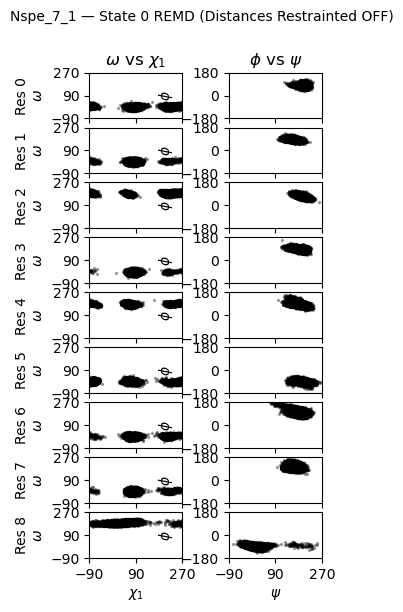

Plotting Cluster 6 with 4701 frames


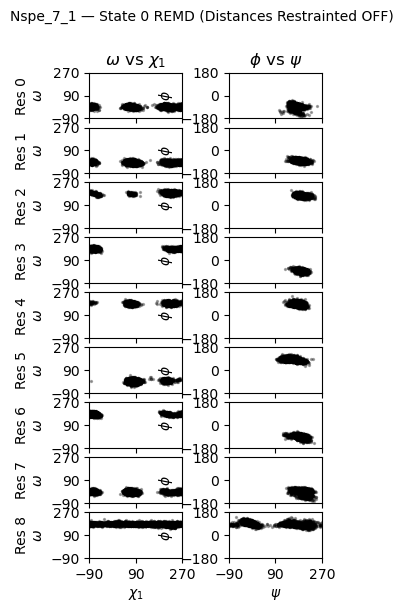

Plotting Cluster 2 with 388 frames


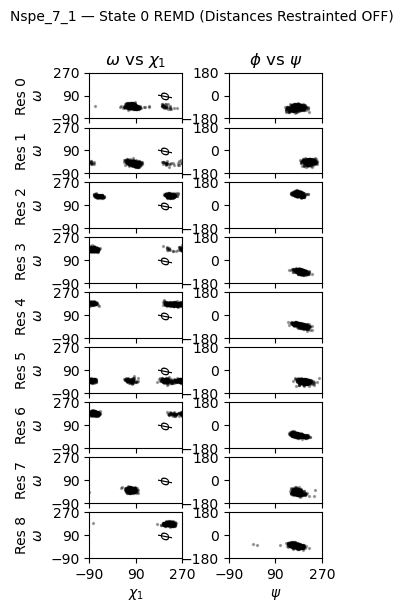

Plotting Cluster 78 with 21001 frames


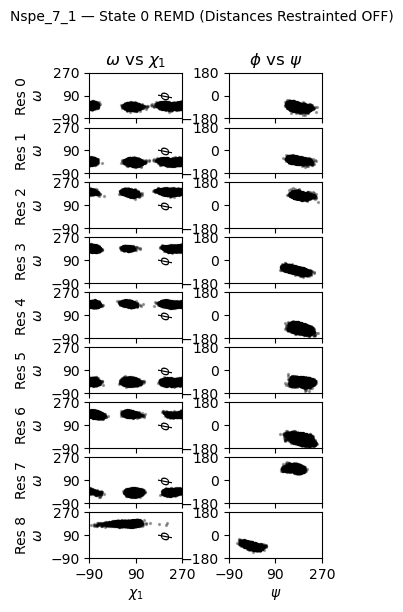

Plotting Cluster 166 with 6064 frames


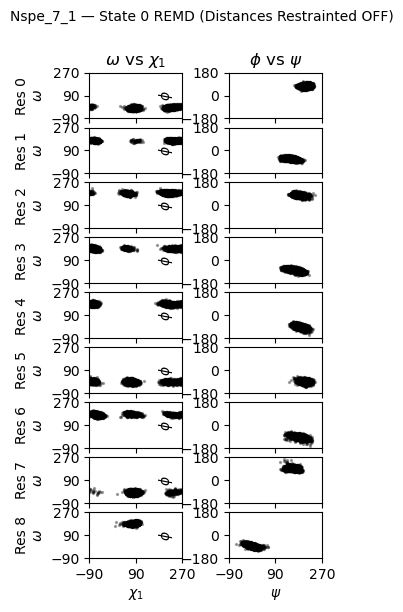

In [35]:
# Available options for angles_to_plot:

# "phi_psi"      # Plot ψ vs φ
# "omega_phi"    # Plot φ vs ω
# "omega_psi"    # Plot ψ vs ω
# "omega_chi1"   # Plot χ₁ vs ω
# "phi_chi1"     # Plot χ₁ vs φ
# "psi_chi1"     # Plot χ₁ vs ψ

residues_to_plot = np.arange(0, 36, 4).tolist()  # Modify if needed



angles_to_plot = ["omega_chi1", "phi_psi"]  # customize as needed

for label, indices in top_cluster.items():
    omega_input = omegas[indices, :][np.newaxis, ...]  # shape becomes (1, n_frames, 24)

    print(f"Plotting Cluster {label} with {indices.shape[0]} frames")

    plot_dihedral_quadruplets(
        omega_all=omega_input,
        residues_to_plot=residues_to_plot,
        states=[0],  # Only 1 cluster at a time
        use_latex=True,
        angles_to_plot=angles_to_plot
    )

## Filter The Cluster Based On RMSD

In [28]:
## Create the equivalent proton set
restraint_index = pd.factorize(labels)[0] + 1
print(restraint_index)

## Creat their weight
counts = pd.Series(restraint_index).value_counts()
weights = pd.Series(restraint_index).map(lambda x: 1 / counts[x])
weights = weights.to_list()
print("Weights:", weights)

## Prepare Target/ Experimental NMR Distance 
print('NMR Distance', targets)

[ 1  1  1  1  2  2  2  2  3  3  3  3  3  3  4  4  5  5  5  5  5  5  6  6
  6  6  7  7  7  7  8  8  8  8  9  9  9  9  9  9 10 10 10 10 10 10 10 10
 10 11 11 11 11 11 11 11 11 11 12 12 13 13 13 13 13 13 14 14 14 14 14 14
 15 15 15 15 15 15 16 16 17 17 17 17 17 17 18 18 18 18 18 18 19 19 19 19
 19 19 20 20 20 20 20 20 21 21 21 21 21 21 22 22 22 22 23 23 24 24 24 24
 24 24 25 25 26 26 27 27 27 27 28 28 29 29 29 29 29 29 30 30 31 31 32 32
 32 32 33 33 33 33 33 33 34 34 34 34]
Weights: [0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.5, 0.5, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.1111

In [30]:
filtered_cluster = {label: [] for label in top_cluster}

for cluster_label, frame_indices in top_cluster.items():
    rmsd_list = []

    for idx in frame_indices:
        dist = feat_all[idx, :156]  # predicted distances
        diff = dist - targets      # element-wise difference
        weighted_sq_diff = weights * (diff ** 2)
        rmsd_value = np.sqrt(np.sum(weighted_sq_diff) / np.sum(weights))

        # Save both index and RMSD
        rmsd_list.append((idx, rmsd_value))

    # Sort by RMSD value and take the lowest 20
    sorted_rmsd = sorted(rmsd_list, key=lambda x: x[1])[:10]

    # Append only the indices of the lowest 20 RMSDs
    filtered_cluster[cluster_label] = [idx for idx, _ in sorted_rmsd]

### Plot

Label: H02 1 H12 23 - H02 1 H1 12
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H12 23 - H02 1 H2 13
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H02 1 H13 24 - H02 1 H1 12
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H13 24 - H02 1 H2 13
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H10 136 - H02 1 H1 12
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H10 136 - H02 1 H2 13
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H11 137 - H02 1 H1 12
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H11 137 - H02 1 H2 13
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H

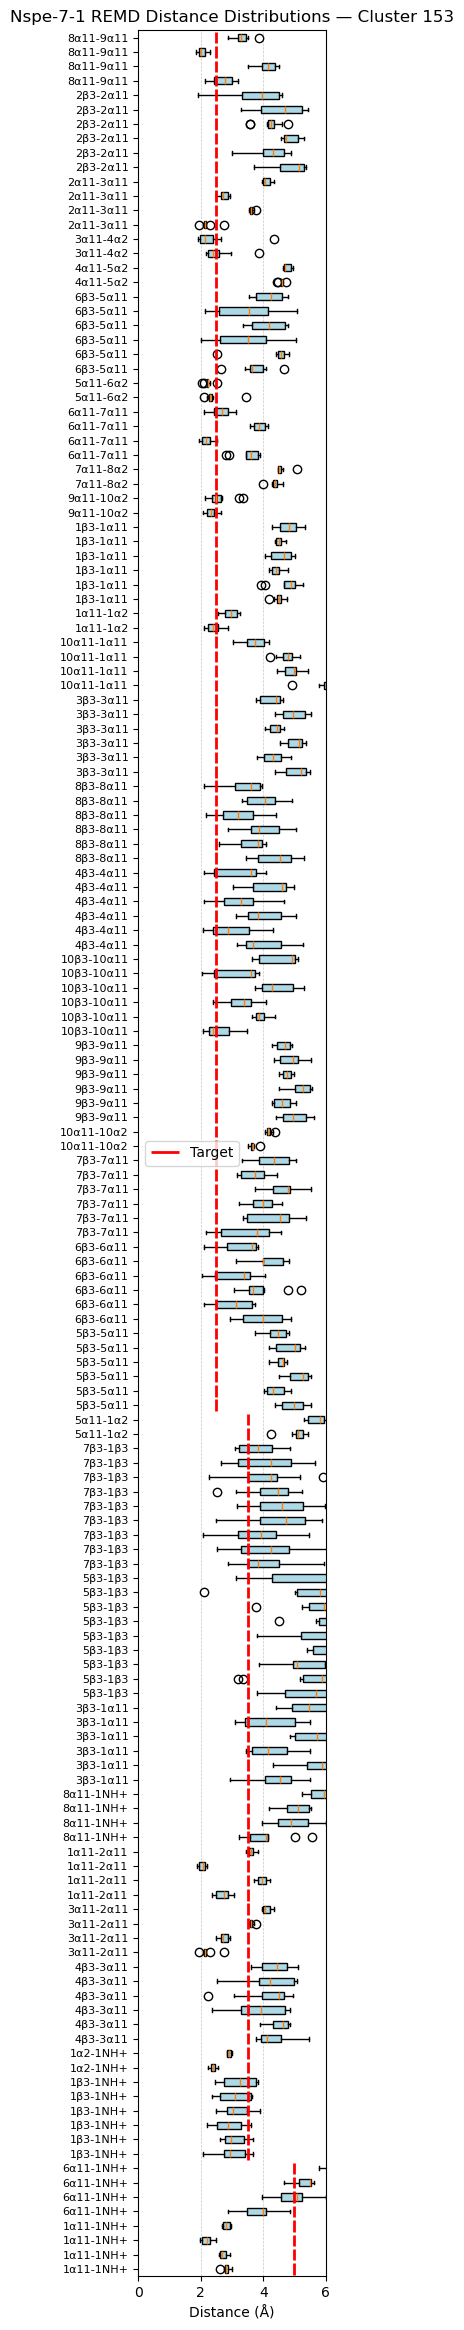

Label: H02 1 H12 23 - H02 1 H1 12
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H12 23 - H02 1 H2 13
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H02 1 H13 24 - H02 1 H1 12
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H13 24 - H02 1 H2 13
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H10 136 - H02 1 H1 12
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H10 136 - H02 1 H2 13
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H11 137 - H02 1 H1 12
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H11 137 - H02 1 H2 13
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H

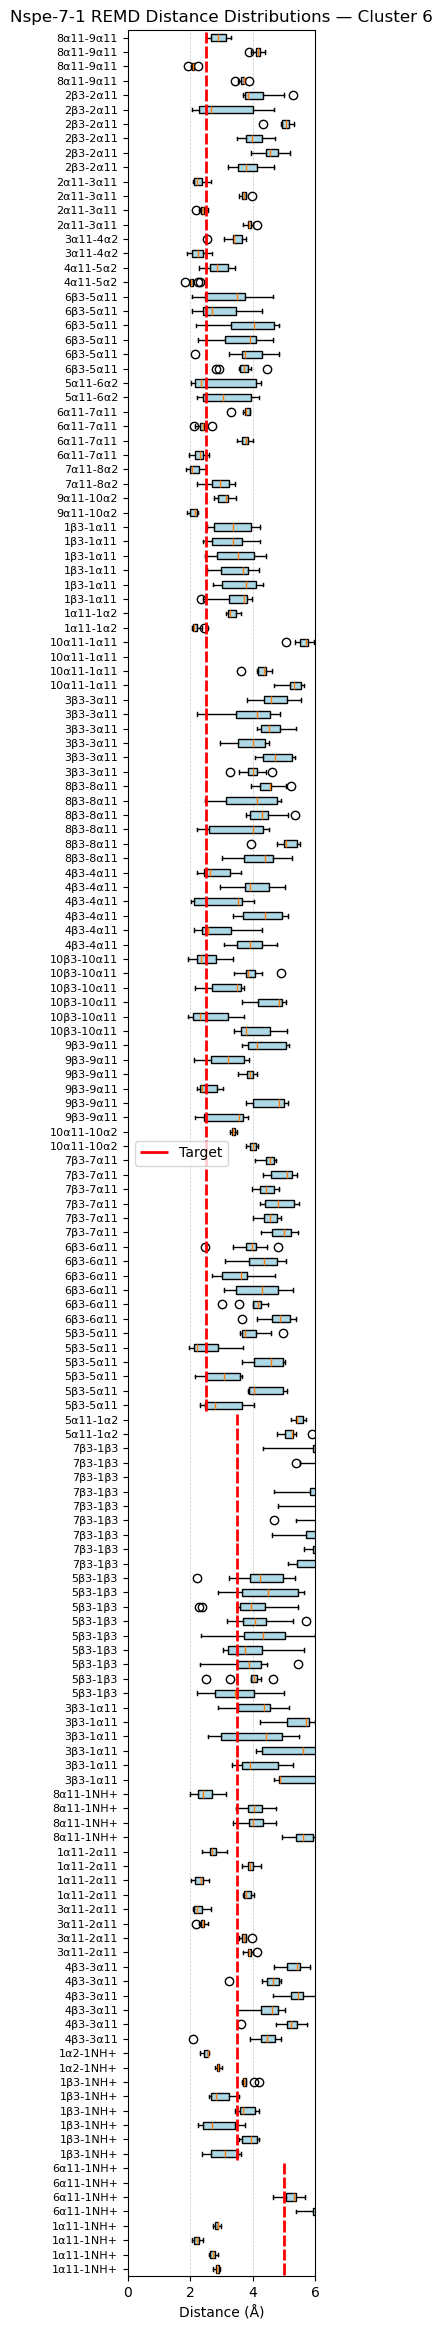

Label: H02 1 H12 23 - H02 1 H1 12
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H12 23 - H02 1 H2 13
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H02 1 H13 24 - H02 1 H1 12
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H13 24 - H02 1 H2 13
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H10 136 - H02 1 H1 12
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H10 136 - H02 1 H2 13
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H11 137 - H02 1 H1 12
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H11 137 - H02 1 H2 13
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H

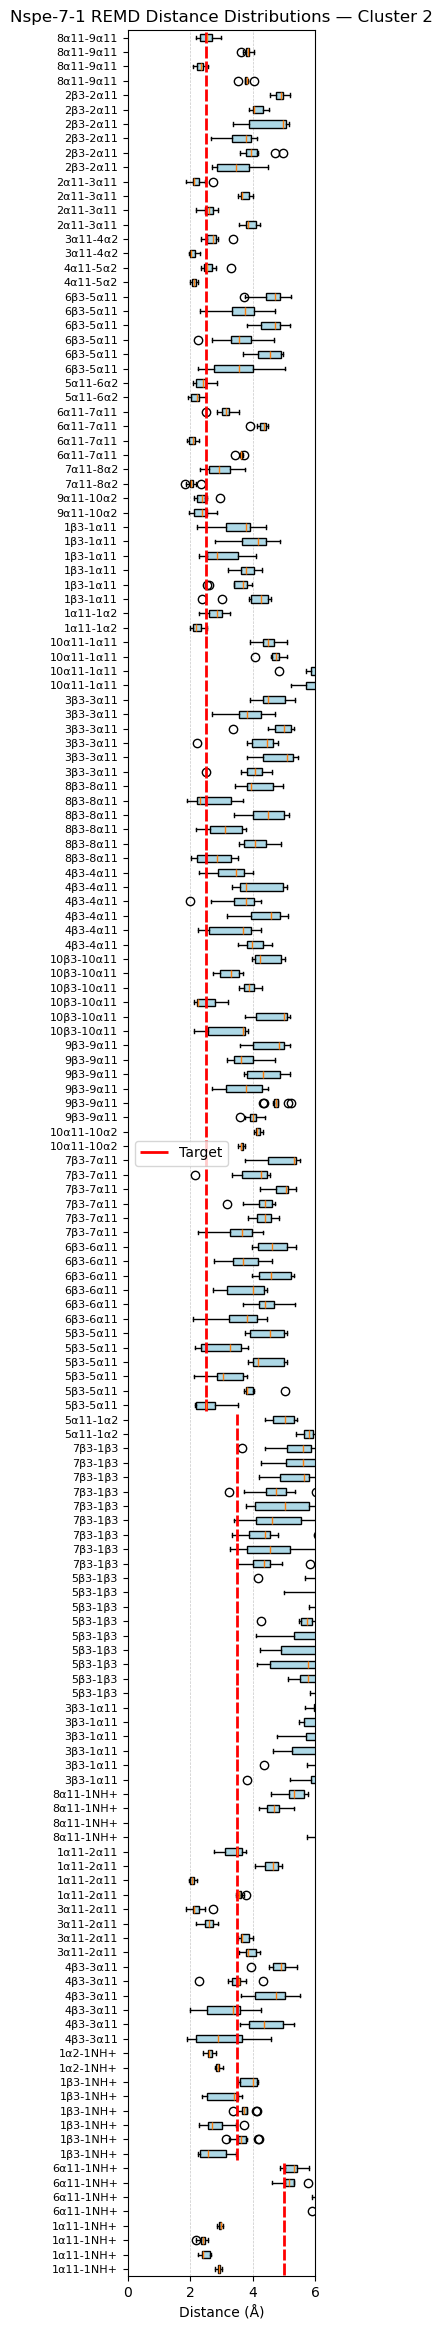

Label: H02 1 H12 23 - H02 1 H1 12
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H12 23 - H02 1 H2 13
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H02 1 H13 24 - H02 1 H1 12
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H13 24 - H02 1 H2 13
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H10 136 - H02 1 H1 12
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H10 136 - H02 1 H2 13
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H11 137 - H02 1 H1 12
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H11 137 - H02 1 H2 13
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H

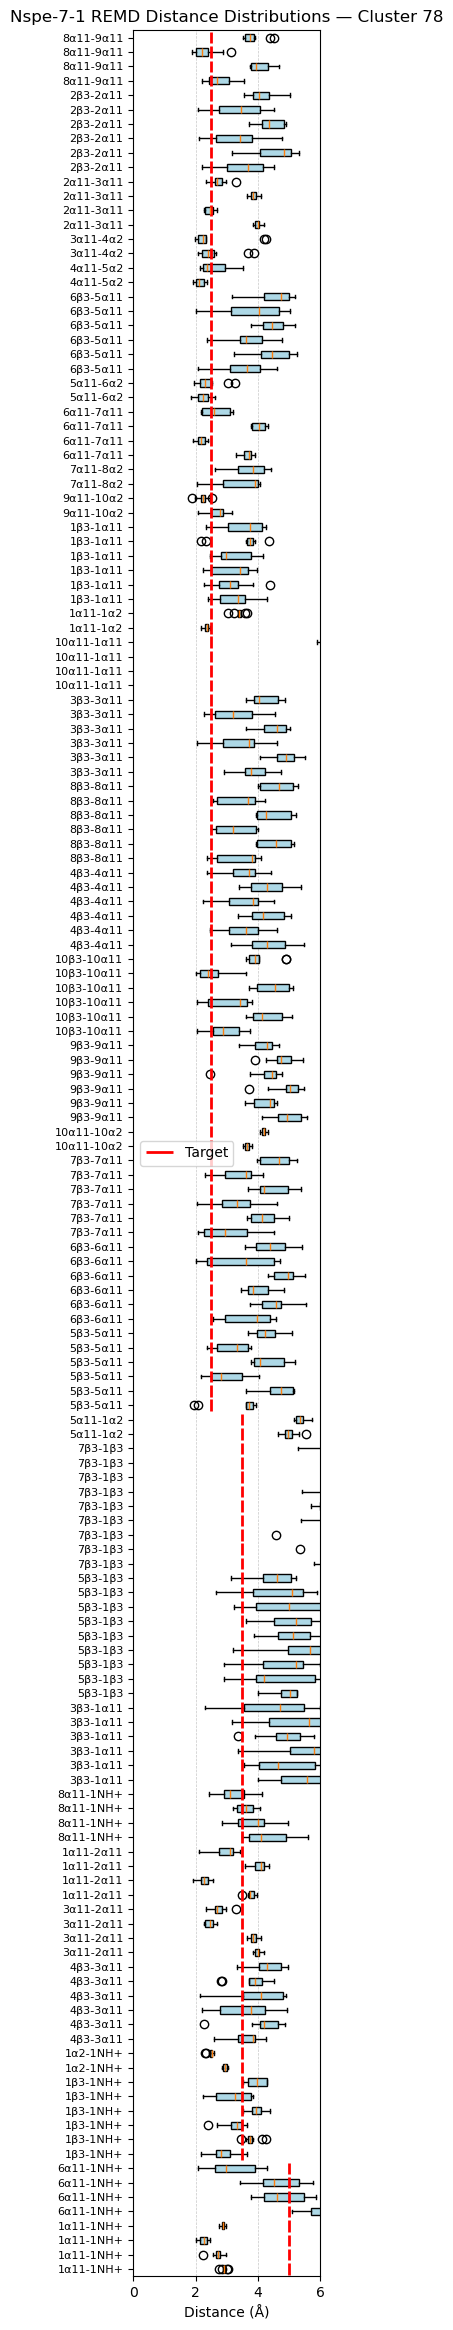

Label: H02 1 H12 23 - H02 1 H1 12
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H12 23 - H02 1 H2 13
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H02 1 H13 24 - H02 1 H1 12
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: H02 1 H13 24 - H02 1 H2 13
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H10 136 - H02 1 H1 12
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H10 136 - H02 1 H2 13
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: R02 6 H11 137 - H02 1 H1 12
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H1 (12), Group: NH+
Label: R02 6 H11 137 - H02 1 H2 13
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: H02 1, Atom: H2 (13), Group: NH+
Label: H

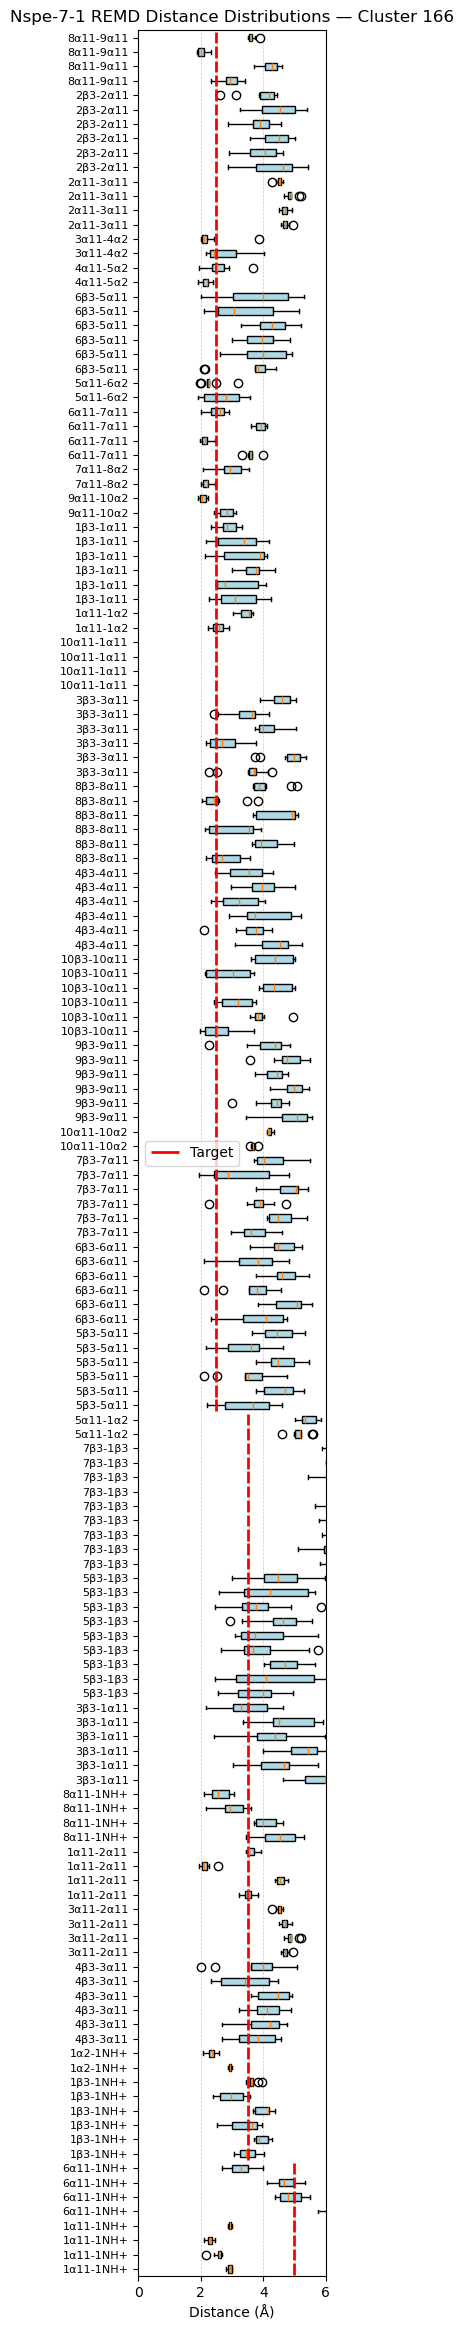

In [32]:
human_interpretable_label = True
grofile = "../nspe_10.amb2gmx/nspe_10_GMX.gro"

for cluster_label, frame_indices in filtered_cluster.items():
    targets = []
    labels = []
    all_dists = []

    cluster_feat = feat_all[frame_indices]
    dist_feat = cluster_feat[:, :156]

    for i, (atom1, atom2, target) in enumerate(dist_res):
        dist = dist_feat[:, i]
        all_dists.append(dist)
        targets.append(target)

        atom1_pyemma = atom1 - 1
        atom2_pyemma = atom2 - 1
        feat = pyemma.coordinates.featurizer(grofile)
        feat.add_distances([[atom1_pyemma, atom2_pyemma]])
        label = feat.describe()[0]

        if human_interpretable_label:
            #labels.append(f"{i}: {translate_pyemma_label(label=label)}")
            labels.append(f"{translate_pyemma_label(label=label)}")
        else:
            labels.append(label)

    targets = np.array(targets)

    plt.figure(figsize=(3, max(6, len(labels) * 0.15)))

    # Boxplot: transpose the list of arrays into required format
    bp = plt.boxplot(all_dists, vert=False, patch_artist=True, labels=labels)

    # Custom styling for boxes
    for box in bp['boxes']:
        box.set(facecolor='lightblue')

    # Add red target lines
    for yi, ti in enumerate(targets, start=1):  # boxplot y starts at 1
        plt.vlines(ti, yi - 0.4, yi + 0.4, colors='red', linestyles='-', linewidth=2, label='Target' if yi == 1 else "")

    plt.yticks(fontsize=8)
    plt.xlabel("Distance (Å)")
    plt.title(f"Nspe-7-1 REMD Distance Distributions — Cluster {cluster_label}")
    plt.xlim(0, 6)
    plt.legend()
    plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()

Plotting Cluster 153 with 10 frames


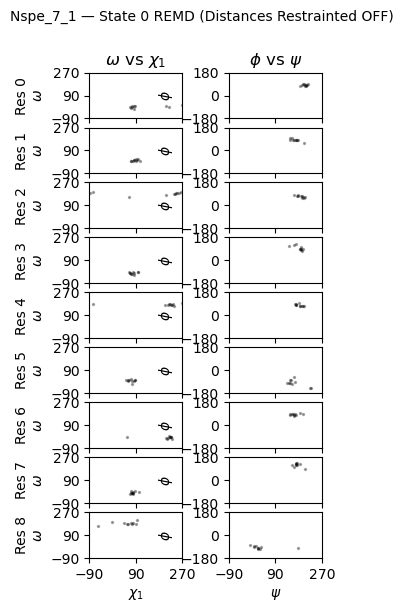

Plotting Cluster 6 with 10 frames


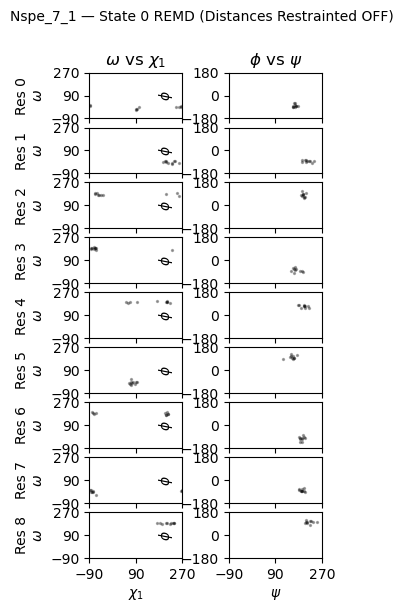

Plotting Cluster 2 with 10 frames


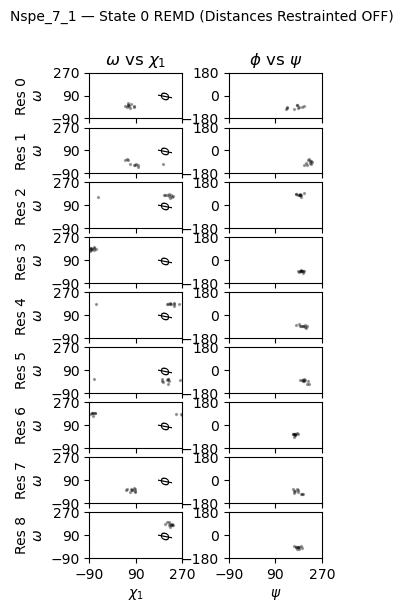

Plotting Cluster 78 with 10 frames


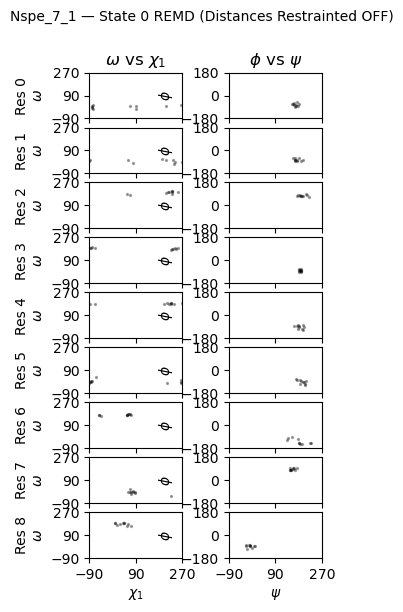

Plotting Cluster 166 with 10 frames


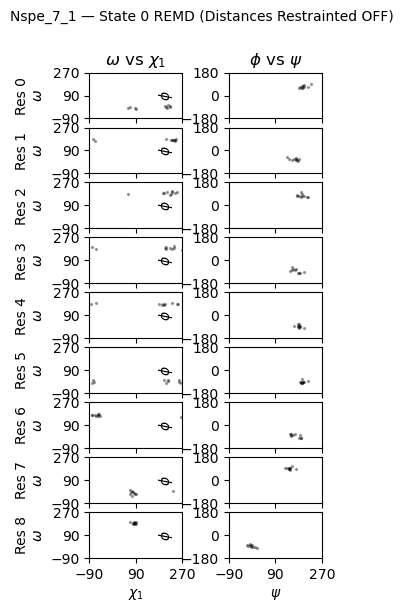

In [39]:
angles_to_plot = ["omega_chi1", "phi_psi"]  # customize as needed

for label, indices in filtered_cluster.items():
    omega_input = omegas[indices, :][np.newaxis, ...]  # shape becomes (1, n_frames, 24)

    print(f"Plotting Cluster {label} with {omega_input.shape[1]} frames")

    plot_dihedral_quadruplets(
        omega_all=omega_input,
        residues_to_plot=residues_to_plot,
        states=[0],  # Only 1 cluster at a time
        use_latex=True,
        angles_to_plot=angles_to_plot
    )

## Sampling

In [37]:
# Define the directory path
directory = "sampling/"

# Check if the directory exists
if os.path.exists(directory):
    # Remove all contents of the directory
    shutil.rmtree(directory)
    # Recreate the empty directory
    os.makedirs(directory)
    print(f"All contents in '{directory}' have been cleared.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

All contents in 'sampling/' have been cleared.


In [38]:
# Load all trajectories and join
HREX_dir = '../traj_remd'
run_num = 15
trajs = []
HREX_list = [f"REMD_200ns_{i}" for i in range(1, run_num + 1)]

for HREX in HREX_list:
    HREX_path = f"{HREX_dir}/{HREX}"  
    xtcfile = f"{HREX_path}/state_0/HREMD.part0001_intact.xtc"
    grofile = f"../nspe_10.amb2gmx/nspe_10_GMX.gro"
    traj = md.load(xtcfile, top=grofile)
    trajs.append(traj)

# Concatenate all trajectories
concatenated_trajs = md.join(trajs)

# Save sampled frames for each selected cluster using filtered_cluster
for label, frame_indices in filtered_cluster.items():
    print('label', label, "frame_indices", frame_indices)
    sampling = concatenated_trajs[frame_indices]  # extract frames
    sampling.save_xtc(f"sampling/sample_state_0_cluster{label}.xtc")
    sampling.save_pdb(f"sampling/sample_state_0_cluster{label}.pdb")


label 153 frame_indices [56404, 56541, 56463, 56477, 202954, 56345, 56380, 56689, 56657, 56491]
label 6 frame_indices [3382, 3407, 295, 3424, 3358, 285, 270, 314, 303, 294]
label 2 frame_indices [2698, 6343, 2304, 2516, 2521, 2203, 5812, 2523, 2991, 2393]
label 78 frame_indices [126412, 245081, 35854, 52075, 168437, 118435, 179505, 267329, 52071, 126635]
label 166 frame_indices [116930, 75758, 82310, 68951, 111672, 153808, 87757, 111666, 111661, 139304]
